# Team 01 — Polynomial Model Complexity and Generalization

**Research question:** When does increasing model complexity stop improving generalization?

This notebook investigates how polynomial degree affects training and validation/test performance on the UCI Wine Quality dataset.

## 1. Investigation Plan

We will compare Polynomial Regression models with degrees **1, 2, 3, 4, and 5** while keeping the dataset, split, preprocessing strategy, and learning algorithm controlled.

Primary metric: **RMSE**

Supporting metrics: **MAE** and **R²**

The test set will be kept separate and used only for the final evaluation after model complexity is selected using validation performance.

## 1.1 Hypothesis

We hypothesize that increasing polynomial degree will initially improve model performance because a more flexible model can capture more complex relationships between the input features and wine quality.

However, after an appropriate complexity level is reached, further increases in polynomial degree are expected to reduce validation/test performance. This is because the model may begin to fit patterns specific to the training data rather than generalizable relationships.

Therefore, we expect training error to decrease as model complexity increases, while validation error will eventually stop improving and may increase, indicating overfitting.

In [ ]:
# Cell 1 — Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
print('Libraries imported successfully.')

Libraries imported successfully.


In [ ]:
# Cell 2 — Load the UCI Wine Quality (red wine) dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Cell 3 — Inspect the dataset
print('Columns:')
print(df.columns.tolist())

print('\nMissing values:')
print(df.isna().sum())

print('\nTarget distribution:')
print(df['quality'].value_counts().sort_index())

print('\nSummary statistics:')
display(df.describe().T)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Target distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


### Why we inspect the data first

Before training anything, we need to understand the number of observations, available features, missing values, feature scales, and the target variable. This supports the dataset justification required in the course project.

In [ ]:
# Cell 4 — Separate features and target
X = df.drop(columns='quality')
y = df['quality']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Number of input features:', X.shape[1])

Feature matrix shape: (1599, 11)
Target shape: (1599,)
Number of input features: 11


In [ ]:
# Cell 5 — Create train / validation / test splits
# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (1119, 11) (1119,)
Validation: (240, 11) (240,)
Test: (240, 11) (240,)


## 1.2 Dataset Justification

The investigation uses the UCI Wine Quality red wine dataset.

The dataset contains 1,599 observations and 11 physicochemical input features, with wine quality as the target variable.

The input features include measurements such as fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, sulfur dioxide, density, pH, sulphates and alcohol.

There are no missing values in the dataset.

This dataset is suitable for the investigation because the same dataset and prediction task can be used while systematically changing only the polynomial degree. This allows us to study how increasing model complexity affects training performance, validation performance and generalization.

The quality scores are concentrated mainly around 5 and 6, while some extreme quality values have relatively few observations. Therefore, the dataset also has limitations in how evenly different target values are represented.

The dataset is used for an investigation of model behaviour rather than for developing a production-quality wine-quality prediction system.

## 1.3 Theoretical Background

### Model Complexity

Model complexity refers to the flexibility of a machine learning model to represent relationships between input variables and the target.

In this investigation, polynomial degree is used as the controllable measure of complexity. A higher polynomial degree allows the model to represent more complex nonlinear relationships and interactions.

### Underfitting

Underfitting occurs when a model is too simple to capture important patterns in the data. Such a model may perform relatively poorly even on the training data.

### Overfitting

Overfitting occurs when a model becomes too flexible and fits patterns that are specific to the training data. Training performance may continue to improve while performance on unseen validation or test data becomes worse.

### Generalization

Generalization refers to how well a model performs on previously unseen data.

A model with good generalization should maintain similar performance when moving from training data to unseen data.

### Bias–Variance Perspective

Increasing model complexity can reduce bias because the model becomes more capable of representing complex relationships. However, excessive complexity can increase variance, making the model more sensitive to the particular training sample.

This creates a trade-off: a model should be complex enough to capture useful patterns but not so complex that it fits noise or sample-specific patterns.

### Polynomial Regression in This Investigation

PolynomialFeatures expands the original input variables by generating higher-order and interaction terms.

As polynomial degree increases, the number of generated features grows rapidly. This increases model flexibility and can improve training performance, but it can also increase the risk of overfitting.

Therefore, comparing training and validation performance across polynomial degrees provides experimental evidence about the relationship between model complexity and generalization.

## 2. Build the polynomial regression experiment

The only experimental variable we change is **polynomial degree**. Everything else remains controlled.

The pipeline standardizes the original features, creates polynomial terms, standardizes the expanded feature matrix, and fits Linear Regression. Keeping preprocessing inside the pipeline prevents validation/test information from leaking into training.

In [ ]:
# Cell 6 — Train and evaluate polynomial models for degrees 1 to 5
degrees = [1, 2, 3, 4, 5]
results = []

for degree in degrees:
    model = Pipeline([
        ('input_scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('poly_scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)

    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)

    n_poly_features = model.named_steps['poly'].n_output_features_

    results.append({
        'degree': degree,
        'poly_features': n_poly_features,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'generalization_gap_rmse': val_rmse - train_rmse,
        'generalization_gap_r2': train_r2 - val_r2,
    })

results_df = pd.DataFrame(results)
results_df

,degree,poly_features,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,generalization_gap_rmse,generalization_gap_r2
0,1,11,6.486807e-01,0.637445,4.951875e-01,0.518364,0.361198,0.318017,-0.011236,0.043181
1,2,77,6.014819e-01,0.627450,4.642753e-01,0.515270,0.450776,0.339237,0.025968,0.111540
2,3,363,4.544370e-01,0.856336,3.403117e-01,0.617836,0.686490,-0.230769,0.401899,0.917259
3,4,1364,1.343687e-13,18.789732,7.132692e-14,6.549741,1.000000,-591.555518,18.789732,592.555518
4,5,4367,3.501685e-14,9.393747,1.878985e-14,3.622357,1.000000,-147.103588,9.393747,148.103588


Polynomial feature growth:


,degree,poly_features
0,1,11
1,2,77
2,3,363
3,4,1364
4,5,4367


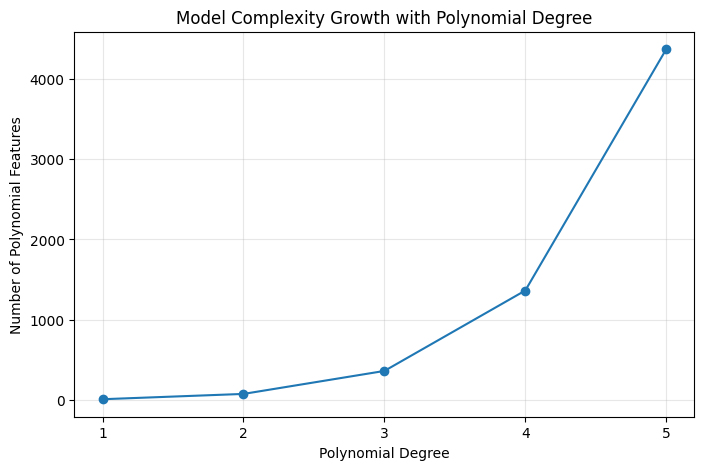

In [ ]:
# Cell 7 — Visualize how model complexity grows

complexity_df = results_df[['degree', 'poly_features']].copy()

print("Polynomial feature growth:")
display(complexity_df)

plt.figure(figsize=(8, 5))
plt.plot(
    complexity_df['degree'],
    complexity_df['poly_features'],
    marker='o'
)
plt.xlabel('Polynomial Degree')
plt.ylabel('Number of Polynomial Features')
plt.title('Model Complexity Growth with Polynomial Degree')
plt.xticks(degrees)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell 8 — Identify the best degree using validation RMSE
best_row = results_df.loc[results_df['val_rmse'].idxmin()]

print(f"Best degree according to validation RMSE: {int(best_row['degree'])}")
print(f"Validation RMSE: {best_row['val_rmse']:.4f}")
print(f"Validation R²: {best_row['val_r2']:.4f}")

Best degree according to validation RMSE: 2
Validation RMSE: 0.6274
Validation R²: 0.3392


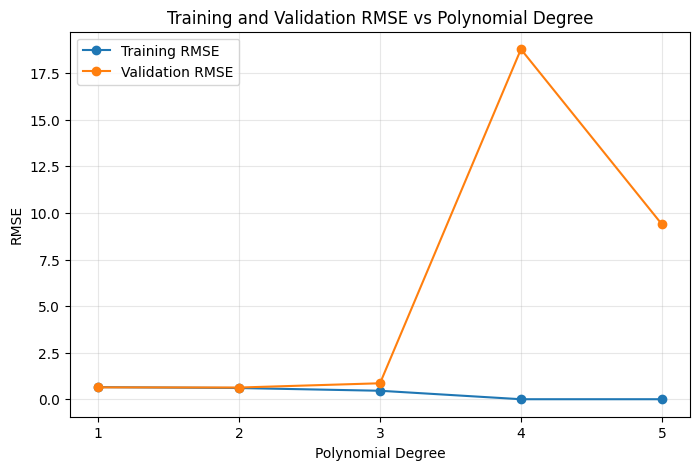

In [ ]:
# Cell 9 — Plot training and validation RMSE
plt.figure(figsize=(8, 5))
plt.plot(results_df['degree'], results_df['train_rmse'], marker='o', label='Training RMSE')
plt.plot(results_df['degree'], results_df['val_rmse'], marker='o', label='Validation RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE vs Polynomial Degree')
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

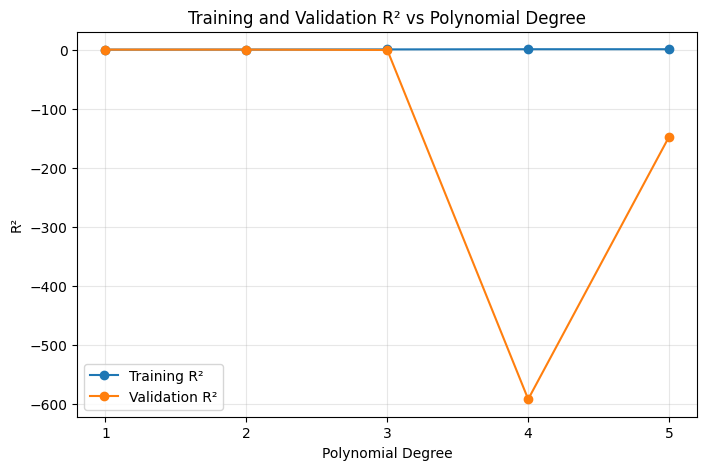

In [ ]:
# Cell 10 — Plot training and validation R²
plt.figure(figsize=(8, 5))
plt.plot(results_df['degree'], results_df['train_r2'], marker='o', label='Training R²')
plt.plot(results_df['degree'], results_df['val_r2'], marker='o', label='Validation R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R²')
plt.title('Training and Validation R² vs Polynomial Degree')
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

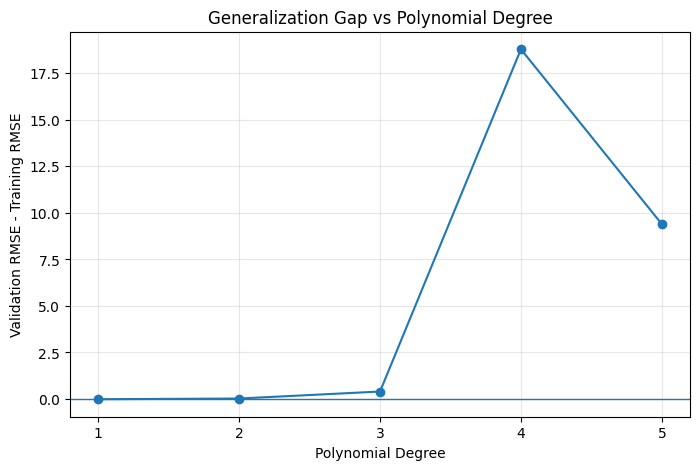

In [ ]:
# Cell 11 — Plot the generalization gap
plt.figure(figsize=(8, 5))
plt.plot(
    results_df['degree'],
    results_df['generalization_gap_rmse'],
    marker='o'
)
plt.axhline(0, linewidth=1)
plt.xlabel('Polynomial Degree')
plt.ylabel('Validation RMSE - Training RMSE')
plt.title('Generalization Gap vs Polynomial Degree')
plt.xticks(degrees)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell 12 — Final test evaluation of the degree selected by validation performance
best_degree = int(best_row['degree'])

final_model = Pipeline([
    ('input_scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('poly_scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print(f'Chosen degree: {best_degree}')
print(f'Test RMSE: {test_rmse:.4f}')
print(f'Test MAE: {test_mae:.4f}')
print(f'Test R²: {test_r2:.4f}')

Chosen degree: 2
Test RMSE: 0.6548
Test MAE: 0.5078
Test R²: 0.3621


## 3.1 Results Analysis and Interpretation

### Training Performance

Training RMSE decreases as polynomial degree increases. The training model therefore fits the training data increasingly well as complexity increases.

At the highest complexity levels, the training RMSE becomes approximately zero and training R² reaches 1.0. This indicates that the high-degree models can fit the training data extremely closely.

### Validation Performance

Validation performance shows a different pattern.

The validation RMSE improves from degree 1 to degree 2, reaching its lowest value at degree 2 (0.6274). However, increasing the degree beyond 2 causes validation performance to deteriorate.

At degree 3, validation RMSE increases to approximately 0.8563. At degree 4 it increases dramatically to approximately 18.79, and at degree 5 it remains extremely high at approximately 9.39.

Therefore, increasing complexity does not continuously improve generalization.

### Evidence of Overfitting

The difference between training and validation performance becomes much larger at higher polynomial degrees.

For degree 3, training RMSE decreases to approximately 0.4544 while validation RMSE increases to approximately 0.8563.

For degrees 4 and 5, the training RMSE is effectively zero while validation RMSE becomes extremely large. At the same time, training R² reaches 1.0 while validation R² becomes strongly negative.

This provides strong experimental evidence that the higher-degree models are fitting the training data much more closely than they can generalize to unseen data.

### Why Does This Happen?

Polynomial features increase the flexibility of the model by allowing combinations and higher-order relationships between the original input variables.

The number of polynomial features grows rapidly as degree increases: from 11 features at degree 1 to 77 at degree 2, 363 at degree 3, 1,364 at degree 4 and 4,367 at degree 5.

This greatly increases the number of patterns the model can represent. At moderate complexity, this additional flexibility can capture useful relationships. Beyond that point, the model can begin fitting patterns that are specific to the training data rather than patterns that generalize well.

This explains the observed behaviour: training performance continues to improve, but validation performance deteriorates.

### Underfitting and Overfitting

Degree 1 provides a relatively simple model and has worse validation performance than degree 2. This is consistent with the possibility of insufficient model flexibility.

Degree 2 provides the best validation performance in this experiment.

Degrees 3, 4 and 5 provide progressively greater flexibility but poorer validation performance, giving evidence of overfitting.

### Selecting the Model

Degree 2 was selected using validation RMSE rather than the test set.

The final test evaluation of the selected degree produced:

- Test RMSE = 0.6548
- Test MAE = 0.5078
- Test R² = 0.3621

The test result is reasonably close to the validation result for degree 2, providing additional support for the validation-based selection.

## 3.2 Robustness Check

The primary experiment uses a fixed train/validation/test split so that polynomial degree is the only intended experimental variable.

To examine whether the observed pattern depends strongly on one particular split, we perform the same degree comparison using several different random train/validation splits.

We expect the exact RMSE values to vary between splits, but the overall relationship between model complexity and generalization should remain similar if the observed conclusion is robust.

In [ ]:
# Cell 13 — Robustness check across different random splits

robustness_seeds = [1, 42, 100]
robustness_results = []

for seed in robustness_seeds:

    X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
        X, y,
        test_size=0.20,
        random_state=seed
    )

    for degree in degrees:

        model = Pipeline([
            ('input_scaler', StandardScaler()),
            ('poly', PolynomialFeatures(
                degree=degree,
                include_bias=False
            )),
            ('poly_scaler', StandardScaler()),
            ('regressor', LinearRegression())
        ])

        model.fit(X_train_r, y_train_r)

        val_pred_r = model.predict(X_val_r)

        val_rmse_r = np.sqrt(
            mean_squared_error(y_val_r, val_pred_r)
        )

        robustness_results.append({
            'seed': seed,
            'degree': degree,
            'val_rmse': val_rmse_r
        })

robustness_df = pd.DataFrame(robustness_results)

display(
    robustness_df.pivot(
        index='degree',
        columns='seed',
        values='val_rmse'
    )
)

print("\nMean validation RMSE across splits:")
display(
    robustness_df.groupby('degree')['val_rmse']
    .agg(['mean', 'std'])
    .reset_index()
)

seed,1,42,100
degree,,,
1,0.618928,0.624520,0.654396
2,0.631847,0.617945,0.645822
3,1.203691,0.810075,0.905754
4,20.276361,133.747854,39.372762
5,11.348649,19.303706,11.374131



Mean validation RMSE across splits:


,degree,mean,std
0,1,0.632615,0.019069
1,2,0.631871,0.013938
2,3,0.973174,0.205286
3,4,64.465659,60.755123
4,5,14.008829,4.585516


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


### Robustness Interpretation

The validation RMSE changes across different train/validation splits, showing that the exact numerical performance depends partly on which observations are included in the training and validation sets.

Degrees 1 and 2 consistently provide the lowest validation errors compared with the higher-degree models. Their mean validation RMSE values are very close: approximately 0.6326 for degree 1 and 0.6319 for degree 2.

The exact best degree is therefore not completely stable across all three splits. Degree 1 performs slightly better in two of the three splits, while degree 2 has the lowest mean validation RMSE overall.

In contrast, degrees 3, 4 and 5 consistently show substantially poorer validation performance. The very large errors for degrees 4 and 5 also vary considerably across splits, providing evidence that highly complex models are particularly unstable and have poor generalization.

Therefore, the robustness check supports the main conclusion that low model complexity generalizes substantially better than high polynomial complexity, while the exact distinction between degrees 1 and 2 is less certain.

## 4. Critical Evaluation and Limitations

### Limitation 1 — Dependence on the Data Split

The primary experiment uses one fixed train/validation/test split. Although this provides a controlled comparison between polynomial degrees, the exact numerical performance may vary with a different split.

### Limitation 2 — Rapid Growth in Polynomial Features

Higher polynomial degrees generate a very large number of features. This increases model complexity substantially and can make the model more sensitive and prone to overfitting.

### Limitation 3 — Dataset Distribution

The target values are not evenly distributed across all quality levels. Most observations are concentrated around the middle quality scores, while extreme quality values are relatively uncommon. Therefore, the observed behaviour may not represent every possible wine-quality distribution.

### Limitation 4 — Model Choice

The investigation focuses specifically on polynomial regression to study the relationship between a controllable notion of model complexity and generalization. Therefore, the conclusions should not automatically be generalized to every type of machine learning model.

## 5. Conclusion

The investigation asked:

**When does increasing model complexity stop improving generalization?**

The experimental evidence shows that increasing polynomial degree improves training performance continuously, but it does not continuously improve validation performance.

Degree 2 produced the best validation RMSE of 0.6274. Beyond degree 2, validation performance worsened while training performance continued to improve.

Degrees 4 and 5 achieved almost perfect training performance but showed extremely poor validation performance, providing strong evidence of overfitting and poor generalization at high complexity levels.

Therefore, for this dataset and experimental setup, the evidence indicates that increasing model complexity is beneficial only up to a point. After degree 2, additional complexity provides no generalization benefit and instead leads to increasingly poor performance on unseen data.

The experiment demonstrates that a model with the lowest training error is not necessarily the model with the best generalization.

### Answer to the research question

In this dataset and experimental setup, increasing polynomial degree beyond degree 2 did not improve generalization and instead substantially worsened validation performance. Degree 2 provides the best validation performance, while higher degrees increasingly overfit the training data.

## 6. AI Usage Declaration

AI tools were used as assistants for understanding machine learning concepts, structuring the investigation, generating and debugging code, and improving documentation.

All generated code was executed and checked, and numerical results were verified from the actual notebook outputs.

AI-generated suggestions were treated as assistance rather than as experimental evidence. The team reviewed the methodology, results, interpretations and conclusions before finalizing them.